# Búsqueda de hiper-parámetros
## Framework Optuna
**Aprendizaje de Máquina - CEIA - FIUBA**

Por último, vamos a hacer una búsqueda de hiperparámetros usando [Optuna](https://optuna.org/). Como vimos en clase, Optuna es un framework que nos permite realizar búsqueda de hiperparámetros de forma más eficiente, y pensado tanto para funcionar de local con nuestra PC en una notebook, como para ser ejecutado en clusters o en la nube.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


In [2]:
default_df = pd.read_csv("./datasets/Default.csv")

default_df["default"] = default_df["default"].apply(lambda x: 1 if x == "Yes" else 0)
default_df["student"] = default_df["student"].apply(lambda x: 1 if x == "Yes" else 0)

# como siempre vamos separando nuestras variables predictoras de la variable a predecir
X = default_df.loc[:, ["balance", "income", "student"]].values
y = default_df.loc[:, "default"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
    random_state=0, stratify=y)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train) 
X_test = sc_x.transform(X_test)

Creemos la función que nos va a permitir evaluar las diferentes combinaciones de hiperparámetros en Optuna:

In [3]:
from sklearn.model_selection import cross_val_score


def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 100)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_float("p", 1.0, 100.0)
    
    classifier_knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)
    
    # Realizamos la validación cruzada
    score = cross_val_score(classifier_knn, X_train, y_train, cv=3, scoring='f1', 
        n_jobs=-1)
    
    return score.mean()

In [4]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """

    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

In [5]:
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1000, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.13840474526459154
Trial 1 achieved value: 0.21324465136902782 with  35.0958% improvement
Trial 2 achieved value: 0.36574250341152337 with  41.6954% improvement
Trial 5 achieved value: 0.3862068965517242 with  5.2988% improvement
Trial 17 achieved value: 0.40493337696885584 with  4.6246% improvement
Trial 52 achieved value: 0.40603530534351145 with  0.2714% improvement


In [6]:
# Obtenemos los mejores hiper-parámetros encontrados
best_params = study.best_params
best_params

{'n_neighbors': 10, 'weights': 'distance', 'p': 69.6525757493747}

In [7]:
# Creamos el clasificador KNeighborsClassifier con los mejores hiperparámetros
classifier_knn_optuna = KNeighborsClassifier(**best_params)
# Entrenamos el clasificador con los datos de entrenamiento
classifier_knn_optuna.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",69.6525757493747
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'mi...ki'


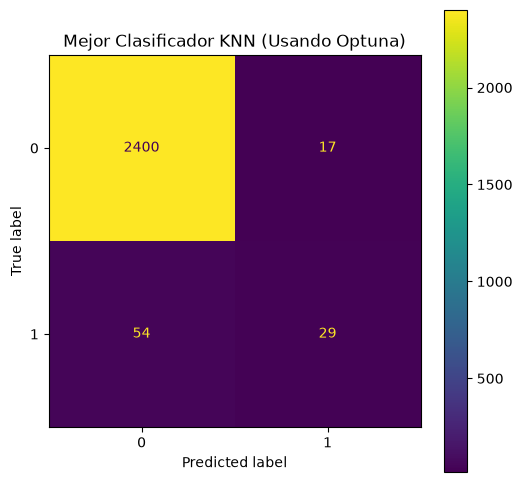

In [8]:
#Evaluamos
y_pred  = classifier_knn_optuna.predict(X_test)

cm_best_knn_optuna = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_best_knn_optuna,
                              display_labels=classifier_knn_optuna.classes_)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax)
ax.set_title("Mejor Clasificador KNN (Usando Optuna)");

In [9]:
# Midamos varias métricas:
print("Mejor Clasificador KNN (Usando Optuna)")
P = np.sum(cm_best_knn_optuna[1, :])
N = np.sum(cm_best_knn_optuna[0, :])
TP = cm_best_knn_optuna[1, 1]
TN = cm_best_knn_optuna[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especifixcidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test, y_pred, zero_division=0)}")

Mejor Clasificador KNN (Usando Optuna)
Sensibilidad: 0.3493975903614458
Especifixcidad: 0.9929664873810509
Exactitud balanceada: 0.6711820388712484
Precision: 0.6304347826086957
Recuperación: 0.3493975903614458
F1-score: 0.4496124031007752


---
Este resultado puede variar con cada ejecución. Para este modelo en particular, dado los pocos hiper-parámetros, es mejor usar la búsqueda por grilla directamente, pero en modelos más grandes (Deep Learning, o en ensambles), el rol de aplicar Optuna toma más importancia. Principalmente porque lo podemos llevar a clusters o a la nube para hacer búsquedas más poderosas.